#Import Libraries

In [2]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

#Loading Datasets

In [3]:
cancer = load_breast_cancer()

#Creating DataFrame

In [4]:
df = pd.DataFrame(cancer.data, columns = cancer.feature_names)

#Adding Target Column

In [5]:
df["target"] = cancer.target

#Displaying Basic Information(shape,columns,info)

In [6]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [7]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

In [8]:
df.shape

(569, 31)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

#Checking Missing Values

In [10]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


#Checking Duplicates

In [11]:
df.duplicated().sum()

np.int64(0)

#Saving the dataset

In [12]:
df.to_csv("breast_cancer_dataset.csv", index = False)
print("Dataset Saved Successfully!")

Dataset Saved Successfully!


#Target Distribution

In [13]:
print(cancer.target_names)

['malignant' 'benign']


#Graph 1

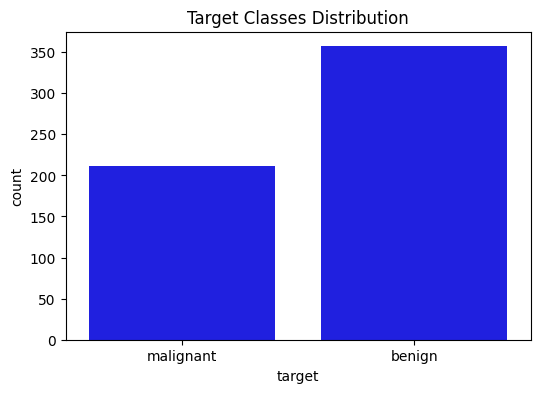

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(x= "target", data=df, color = "blue")
plt.title("Target Classes Distribution")
plt.xlabel("target")
plt.ylabel("count")
plt.xticks([0,1], ["malignant","benign"])
plt.savefig("targetclass_distribution.png")
plt.show()

#Graph 2

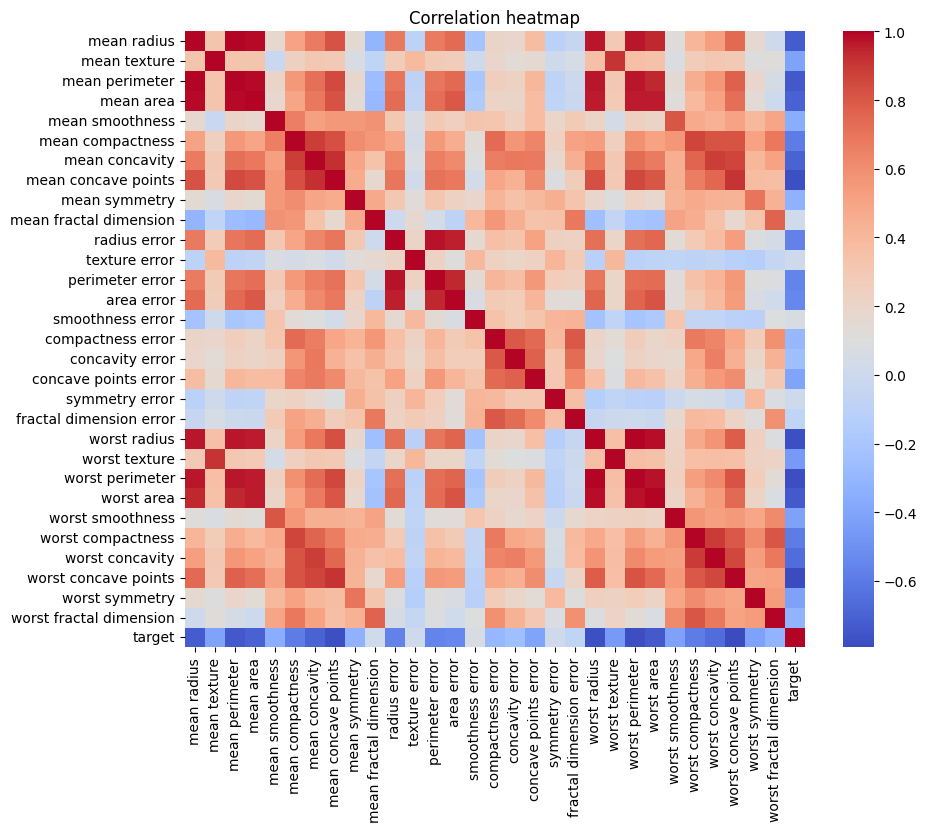

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap = "coolwarm")
plt.title("Correlation heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()

#Separating target and features

In [16]:
x = df.drop("target", axis = 1)
y = df["target"]

#Feature Scaling

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [18]:
print(x_scaled.shape)

(569, 30)


#PCA

In [19]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
x_pca = pca.fit_transform(x_scaled)
print(x_pca.shape)

(569, 2)


In [20]:
pca_df = pd.DataFrame(x_pca, columns = ["Principal Component 1", "Principal Component 2"])
pca_df["target"] = y
pca_df.head()

,Principal Component 1,Principal Component 2,target
0,9.192837,1.948583,0
1,2.387802,-3.768172,0
2,5.733896,-1.075174,0
3,7.122953,10.275589,0
4,3.935302,-1.948072,0


#Visualization of PCA

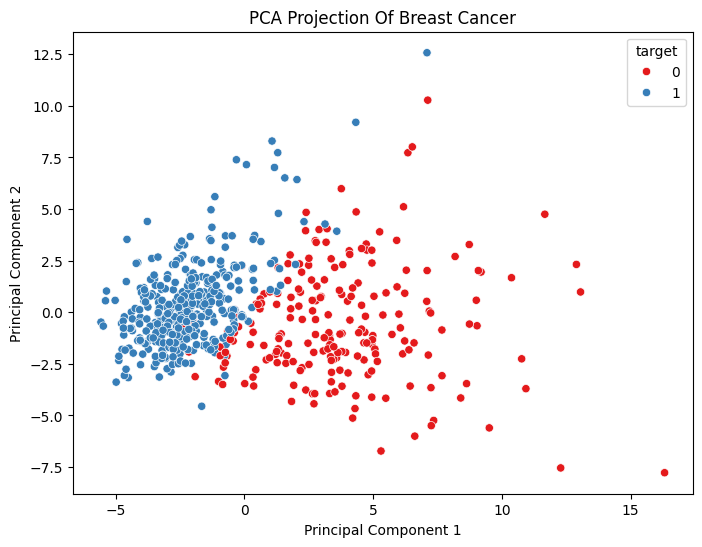

In [21]:
plt.figure(figsize = (8,6))
sns.scatterplot(data = pca_df, x="Principal Component 1", y="Principal Component 2",
                hue = "target", palette= "Set1")
plt.title("PCA Projection Of Breast Cancer")
plt.savefig("pca_projection.png")
plt.show()

#Explained Variance Ratio

In [22]:
print("Explained variance Ratio:")
print(pca.explained_variance_ratio_)

Explained variance Ratio:
[0.44272026 0.18971182]


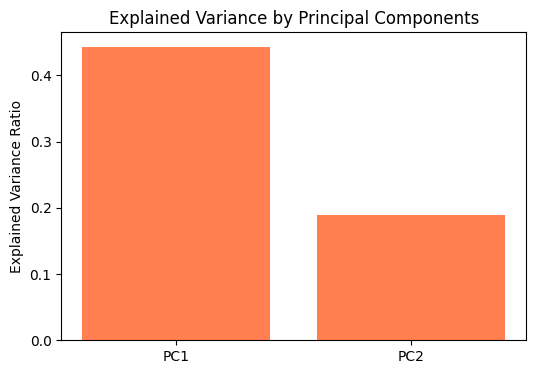

In [23]:
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(6,4))
plt.bar(['PC1', 'PC2'], explained_variance, color = 'coral')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.savefig("Variance_PC.png")
plt.show()

#t-SNE

In [24]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components = 2, random_state = 42, perplexity = 30)
x_tsne = tsne.fit_transform(x_scaled)
print(x_tsne.shape)

(569, 2)


In [26]:
tsne_df = pd.DataFrame(x_tsne, columns = ["Dimension 1", "Dimension 2"])
tsne_df["target"] = y
tsne_df.head()

,Dimension 1,Dimension 2,target
0,37.784595,1.230516,0
1,23.711920,7.329212,0
2,31.739286,3.551559,0
3,20.865301,-13.742583,0
4,26.342352,-1.731673,0


#Visualization of t-SNE

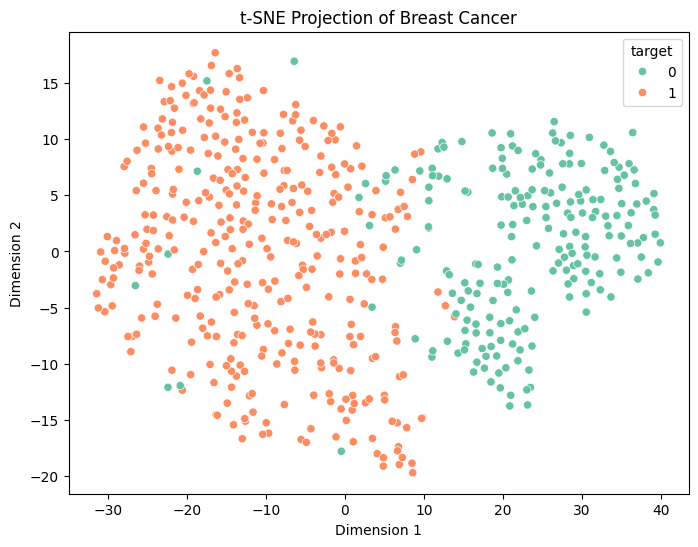

In [34]:
plt.figure(figsize=(8,6))
sns.scatterplot(data = tsne_df, x = "Dimension 1", y = "Dimension 2", hue = "target", palette = "Set2")
plt.title("t-SNE Projection of Breast Cancer")
plt.savefig("tsne_projection.png")
plt.show()

#Comparing PCA and t-SNE

##Features of PCA:
- Type: Linear
- Speed: Fast
- Purpose: Feature Reduction
- Preserves: Global Variance
- Computational Cost: Low
- Suitable for: Preprocessing & Visualization

##Features of t-SNE
- Type: Non-Linear
- Speed: Slow
- Purpose: Data Visualization
- Preserves: Local Structure
- Computational Cost: High
- Suitable for: Visualization

#Conclusion
In this task,Principal Component Analysis(PCA) and t-distributed Stoichastic Neighbor Embedding(t-SNE) were implemented on the Breast Cancer Dataset. PCA successfully reduced the original 30 features to 2 principal components while retaining a significant amount of the datasets variance.

t_SNE also reduced the data to two dimensions and produced a clearer separation between the malignant and benign classes by preserving local relationships among data points.

PCA proved to be faster and more effective for visualization despite its higher computational cost. Both techniques demonstrated the usefulness of dimensionality reduction for simplifying high-dimensional data.